In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

### Dataset

In [2]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv"

In [3]:
!wget $data -O data_home_3.csv

--2026-10-10 16:17:21--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘data_home_3.csv’

data_home_3.csv     100%[===================>] 272.21K  --.-KB/s    in 0.004s  

2026-10-10 16:17:22 (60.1 MB/s) - ‘data_home_3.csv’ saved [278746/278746]



### Data preparation

In [4]:
df = pd.read_csv('data_home_3.csv')
df.head().T

,0,1,2,3,4
lead_source,organic_search,social_media,referral,paid_ads,referral
industry,technology,technology,retail,manufacturing,manufacturing
employment_status,employed,employed,employed,student,student
location,europe,south_america,europe,NaN,north_america
annual_income,88160.0,72688.0,44697.0,NaN,24062.0
number_of_courses_viewed,3,3,3,3,4
interaction_count,4,7,4,6,5
lead_score,0.64,0.72,0.58,0.57,0.62
converted,1,1,1,0,1


In [5]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [6]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [7]:
df = df.fillna({
    col: 'NA' if df[col].dtype == 'str' else 0.0
    for col in df.columns
})

### Question 1: mode for industry

What is the most frequent observation (mode) for the column `industry`?

In [8]:
df['industry'].unique()

<StringArray>
[   'technology',        'retail', 'manufacturing',     'education',
    'healthcare',            'NA',       'finance']
Length: 7, dtype: str

In [9]:
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [10]:
print("The most frequent observation in `industry` is: ", df['industry'].value_counts().idxmax())

The most frequent observation in `industry` is:  technology


### Question 2: biggest correlation 

In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

In [11]:
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

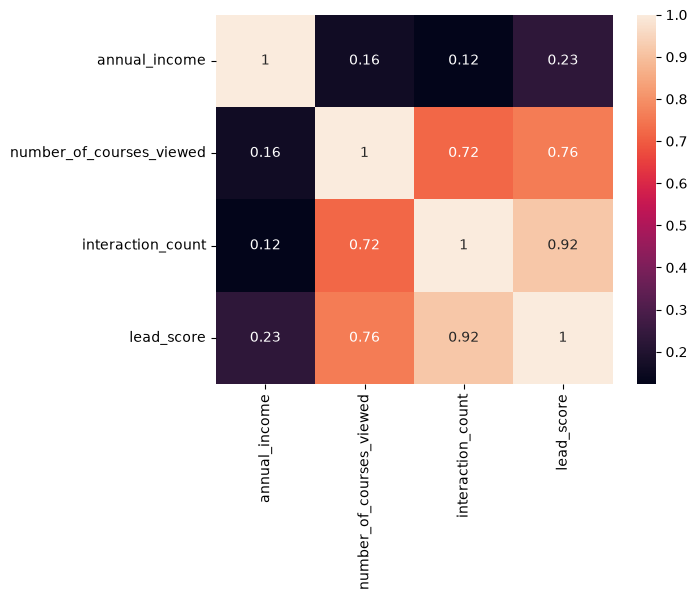

In [12]:
corr_matrix = df[numerical].corr()

sns.heatmap(corr_matrix, annot=True)
plt.show()

In [13]:
corr = df[numerical].corr()
corr = corr.mask(np.eye(len(corr),dtype=bool))
corr.stack()

annual_income             annual_income                    NaN
                          number_of_courses_viewed    0.161300
                          interaction_count           0.122842
                          lead_score                  0.229496
number_of_courses_viewed  annual_income               0.161300
                          number_of_courses_viewed         NaN
                          interaction_count           0.721609
                          lead_score                  0.757204
interaction_count         annual_income               0.122842
                          number_of_courses_viewed    0.721609
                          interaction_count                NaN
                          lead_score                  0.915746
lead_score                annual_income               0.229496
                          number_of_courses_viewed    0.757204
                          interaction_count           0.915746
                          lead_score                   

In [14]:
a,b = corr.stack().idxmax()
#value = corr.stack().max()

In [15]:
print(f"The two features that have the biggest correlation are {a} and {b}.")

The two features that have the biggest correlation are interaction_count and lead_score.


### Split the data

In [16]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 42)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 42)

In [17]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [18]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 3: biggest MI

In [19]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [20]:
def mutual_info_converted_score(series):
    return mutual_info_score(series, y_train)

In [21]:
mi = df_train[categorical].apply(mutual_info_converted_score)
round(mi.sort_values(ascending=False), 2)

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64

In [22]:
print("The variable with the biggest mutual information is: ", mi.idxmax())

The variable with the biggest mutual information is:  lead_source


### Question 4: accuracy

Let's train a logistic regression, including all the variables with one-hot encoding.

Fit the model on training set and calculate the accuracy on the validation dataset and round it to 2 decimal digits.

In [23]:
dv = DictVectorizer(sparse=False)

In [24]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
X_train.shape

(3000, 28)

In [25]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)
X_val.shape

(1000, 28)

In [26]:
model = LogisticRegression(solver = 'liblinear', C = 1.0, max_iter = 1000, random_state = 42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [27]:
y_pred = model.predict_proba(X_val)[:,1]
converted_decision = (y_pred >= 0.5)

In [28]:
accuracy = (y_val == converted_decision).mean()
print(f"The accuracy on the validation set is: {accuracy:.2f}")

The accuracy on the validation set is: 0.65


### Question 5: feature selection

Let's find the least useful feature using the _feature elimination_ technique.
- Train a model using the same features and parameters as in Question 4 (without rounding).
- Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
- For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

In [29]:
full_features = df.columns.to_list()
full_features.remove('converted')

train_dict = df_train[full_features].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[full_features].to_dict(orient='records')
X_val = dv.transform(val_dict)

model = LogisticRegression(solver = 'liblinear', C = 1.0, max_iter = 1000, random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:,1]
converted_decision = (y_pred >= 0.5)
original_accuracy = (y_val == converted_decision).mean()
print("Original accuracy: ", original_accuracy)

Original accuracy:  0.645


In [30]:
results = []

features_to_remove = ['lead_source', 'number_of_courses_viewed', 'interaction_count']

for i in features_to_remove:

    features_without_i = [f for f in full_features if f != i]

    train_dict = df_train[features_without_i].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[features_without_i].to_dict(orient='records')
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver = 'liblinear', C = 1.0, max_iter = 1000, random_state = 42)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]
    converted_decision = (y_pred >= 0.5)
    accuracy = (y_val == converted_decision).mean()

    results.append({'feature': i, 'accuracy': accuracy, 'difference': original_accuracy - accuracy})

df_results = pd.DataFrame(results)

print(df_results)
print(" ")
print("Feature with the smallest difference:",df_results.loc[df_results['difference'].idxmin(), 'feature'])

                    feature  accuracy  difference
0               lead_source     0.642       0.003
1  number_of_courses_viewed     0.643       0.002
2         interaction_count     0.601       0.044
 
Feature with the smallest difference: number_of_courses_viewed


### Question 6: parameter tuning

Now let's train a regularized logistic regression.
- Let's try the following values of the parameter `C`: `[0.000001, 0.00001, 0.0001, 0.001]`.
- Train models using all the features as in Question 4.
- Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

In [31]:
C = [0.000001, 0.00001, 0.0001, 0.001]

results = []

for c in C:

    train_dict = df_train[full_features].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[full_features].to_dict(orient='records')
    X_val = dv.fit_transform(val_dict)

    model = LogisticRegression(solver = 'liblinear', C = c, max_iter = 1000, random_state = 42)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]
    converted_decision = (y_pred >= 0.5)
    accuracy = round((y_val == converted_decision).mean(),3)

    results.append({'C': c, 'accuracy': accuracy})

df_results = pd.DataFrame(results)

print(df_results)
print(" ")
print("Best parameter C which leads to the best accuracy on validation set: ",df_results.loc[df_results['accuracy'].idxmax(), 'C'])

          C  accuracy
0  0.000001     0.598
1  0.000010     0.598
2  0.000100     0.613
3  0.001000     0.645
 
Best parameter C which leads to the best accuracy on validation set:  0.001
